In [9]:
from ultralytics import YOLO
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [29]:
def imshow(img, title='', dpi=80):
    """
    https://stackoverflow.com/a/42314798
    """
    ch = img.shape[2] if len(img.shape) == 3 else 1
    height, width = img.shape[:2]

    # What size does the figure need to be in inches to fit the image?
    figsize = width / float(dpi), height / float(dpi)
    fig = plt.figure(figsize=figsize)
    ax = fig.add_axes([0, 0, 1, 1])

    # Hide spines, ticks, etc.
    ax.axis('off')
    if title:
        ax.set_title(title)

    # Display the image.
    if ch == 1:
        ax.imshow(img, cmap='gray')
    else:
        ax.imshow(img)
    plt.show()

In [11]:
model = YOLO('F:/models/yolov8/yolov8n-seg.pt')

In [12]:
img_path = 'F:/data/VOC/VOC2007/val/images/007935.jpg'
img = cv2.imread(img_path)
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
results = model(rgb)[0]


0: 480x640 2 dogs, 1 couch, 80.6ms
Speed: 7.4ms preprocess, 80.6ms inference, 7.0ms postprocess per image at shape (1, 3, 480, 640)


In [18]:
h, w, *_ = img.shape

In [14]:
cls_num = 80

In [15]:
boxes = results.boxes
masks = results.masks
classes = boxes.cls.cpu().numpy()
scores = boxes.conf.cpu().numpy()
img_segment = np.full((img.shape[0], img.shape[1]), fill_value=cls_num, dtype=np.uint8) # 

In [16]:
results.masks.shape

torch.Size([3, 480, 640])

In [17]:
results.show()

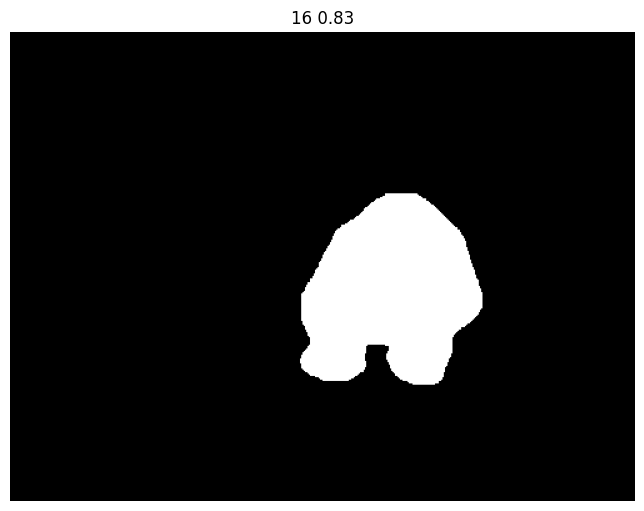

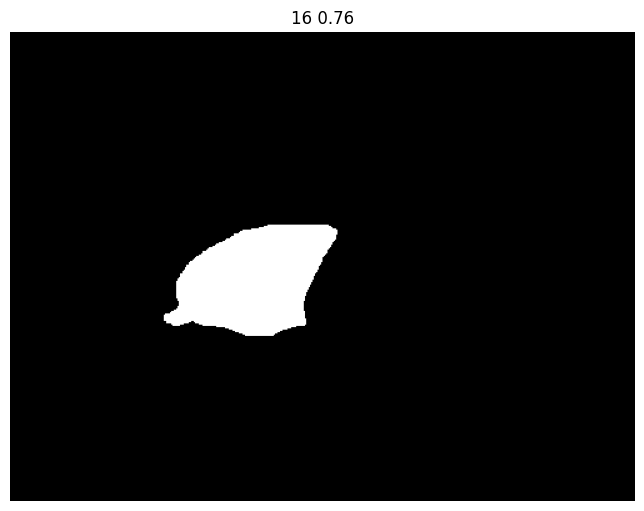

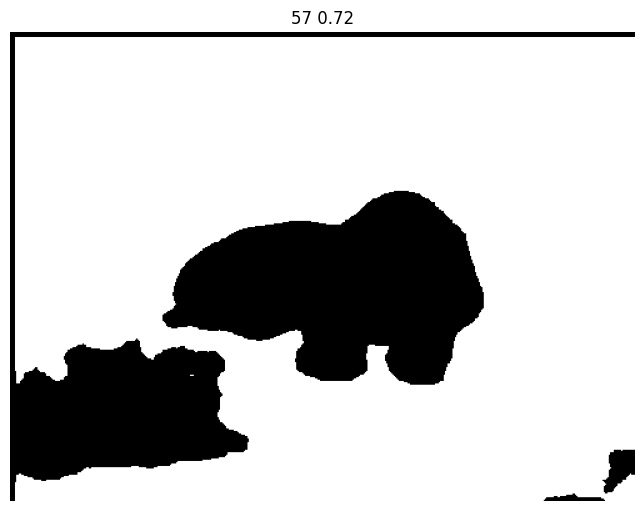

In [30]:
for i in range(len(classes)):
    cls = int(classes[i])
    score = float(scores[i])
    mask = masks[i].data.cpu().numpy().squeeze(0)
    mask = cv2.resize(mask, (w,h), interpolation=cv2.INTER_NEAREST)
    mask = np.where(mask == 1, 255, 0).astype(np.uint8)
    imshow(mask, title=f"{cls} {score:.2f}")


In [24]:
masks[0].data.cpu().numpy()

array([[[          0,           0,           0, ...,           0,           0,           0],
        [          0,           0,           0, ...,           0,           0,           0],
        [          0,           0,           0, ...,           0,           0,           0],
        ...,
        [          0,           0,           0, ...,           0,           0,           0],
        [          0,           0,           0, ...,           0,           0,           0],
        [          0,           0,           0, ...,           0,           0,           0]]], dtype=float32)